<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_08_model_evaluation/stage_08_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_08 – Model Evaluation**

# **Introducción**

El objetivo de este stage es caracterizar completamente el modelo seleccionado antes de usarlo en un sistema de decisión o trading.

Esto incluye varios análisis importantes:

---

**1. Evaluación por régimen de mercado**

Analizar el desempeño del modelo según los distintos **regímenes intradía**:

- pre-market  
- opening  
- regular  
- closing  

Para cada régimen se calcularán las siguientes métricas:

- R²  
- MAE  
- Directional Accuracy (DA)

Este análisis permite responder preguntas clave:

- ¿El modelo funciona mejor durante la apertura?
- ¿Se degrada el desempeño cerca del cierre?
- ¿En qué régimen el modelo es más confiable?

---

**2. Evaluación por magnitud del movimiento**

Separar las predicciones según el **tamaño del movimiento del mercado**.

Ejemplo de partición:

- |delta| < 10 pts  
- 10 ≤ |delta| < 30 pts  
- |delta| ≥ 30 pts  

Este análisis permite evaluar:

- en qué rango el modelo **realmente agrega valor**
- si el modelo **logra capturar correctamente movimientos grandes**
---

**3. Calibration plot (predicción vs realidad)**

Analizar la relación entre:

```
y_pred vs y_true
```

Este gráfico permite detectar:

- sesgo sistemático en las predicciones
- compresión de predicciones
- saturación del modelo

Es una herramienta clave para evaluar **calibración del modelo**.

---

**4. Distribución de errores**

Analizar la distribución del error de predicción:

- histograma de errores
- errores por magnitud de movimiento
- errores por régimen de mercado

Este análisis permite entender **dónde falla el modelo** y en qué condiciones.

---

**5. Sign accuracy condicional**

Evaluar la precisión direccional condicionada a la magnitud de la predicción.

Se calcula la Directional Accuracy cuando:

```
|prediction| > threshold
```

Ejemplo:

| threshold | DA |
|----------|----|
| 5 pts | ? |
| 10 pts | ? |
| 20 pts | ? |

Este análisis es **especialmente relevante para trading**, ya que permite evaluar si el modelo es más confiable cuando predice movimientos más grandes.

---

**6. Curva de utilidad económica (opcional)**

Simular una regla de trading simple:

```
Trade si |predicción| > threshold
```

Evaluar:

- win rate
- promedio de puntos por operación
- expectativa

Este análisis **no constituye un backtest completo**, sino un **sanity check económico del modelo**.

---

**Resultado esperado del Stage 08**

Este stage debe producir un **reporte final del modelo** que incluya:

- performance global
- performance por régimen
- performance por magnitud de movimiento
- análisis detallado de errores
- estabilidad predictiva

En definitiva, este análisis responde a la pregunta fundamental:

**¿Cuándo conviene confiar en el modelo?**

---


### **Posibles extensiones del proyecto**


Una vez completada la evaluación del modelo, el proyecto puede continuar en dos direcciones.

**Opción A — Cierre del proyecto**

Definir el resultado final como:

```
Modelo predictivo intradía para MNQ
```

---

**Opción B — Extensiones futuras**

Explorar nuevas líneas de investigación:

**1. Ensemble de modelos**

```
Transformer + MLP
```

**2. Predicción probabilística**

Predecir:

```
E[delta]
Var(delta)
```

**3. Quantile regression**

Permitiría construir **TP/SL adaptativos**.


# **Reconstrucción de modelos Transformer y MLP**

Antes de comenzar la evaluación del modelo es necesario **cargar los artefactos finales del entrenamiento**.

En el Stage 07 se guardaron los modelos seleccionados junto con sus archivos de resumen (`summary`), que contienen información relevante sobre:

- hiperparámetros finales
- métricas de entrenamiento
- configuración del modelo
- metadatos del experimento

Los modelos finales se encuentran almacenados en el directorio:

```
/content/drive/MyDrive/neural_profit/final_models
```

Modelos a evaluar:

- **Transformer**

```
/content/drive/MyDrive/neural_profit/final_models/transformer_L180_delta_60.pt

```

- **MLP**

```
/content/drive/MyDrive/neural_profit/final_models/mlp_L180_delta_60.pt
```

Cada modelo posee también su archivo de resumen correspondiente:

```
transformer_L180_delta_60_summary.json
mlp_L180_delta_60_summary.json
```

En este paso se cargarán:

- los **pesos del modelo entrenado**
- el **archivo summary**
- los **hiperparámetros necesarios para reconstruir la arquitectura**

Esto permitirá utilizar los modelos para realizar las evaluaciones del **Stage 08** sin necesidad de reentrenarlos.

## **Códigos para reconstrucción de modelos**

In [1]:
import pandas as pd
from pathlib import Path
import os

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# --------------------------------------------------
# Ruta base en Google Drive
# --------------------------------------------------
# Ajuste si su estructura cambia
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

Mounted at /content/drive


### **Función para cargar pesos y modelos entrenados**

In [3]:
from pathlib import Path
import torch
import json

# ============================================================
# Paths
# ============================================================

models_dir = DRIVE_DIR / "final_models"

transformer_path = models_dir / "transformer_L180_delta_60.pt"
transformer_summary_path = models_dir / "transformer_L180_delta_60_summary.json"

mlp_path = models_dir / "mlp_L180_delta_60.pt"
mlp_summary_path = models_dir / "mlp_L180_delta_60_summary.json"

print("Models dir:", models_dir)
print("Transformer:", transformer_path)
print("MLP:", mlp_path)

# ============================================================
# Cargar summaries
# ============================================================

with open(transformer_summary_path, "r") as f:
    transformer_summary = json.load(f)

with open(mlp_summary_path, "r") as f:
    mlp_summary = json.load(f)

# ============================================================
# Cargar state_dict - Solo cargamos el contenido de los archivos .pt
# ============================================================

transformer_state = torch.load(transformer_path, map_location="cpu")
mlp_state = torch.load(mlp_path, map_location="cpu")

print("Modelos cargados correctamente")

Models dir: /content/drive/MyDrive/neural_profit/final_models
Transformer: /content/drive/MyDrive/neural_profit/final_models/transformer_L180_delta_60.pt
MLP: /content/drive/MyDrive/neural_profit/final_models/mlp_L180_delta_60.pt
Modelos cargados correctamente


### **Clase de modelo Transformer**

In [4]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    """
    Positional Encoding sinusoidal (Vaswani et al.).
    Asume entradas con forma (B, L, D) y agrega información de posición.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # pe: (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)  # (max_len, 1)

        # div_term: (d_model/2,) para índices pares
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # pares
        pe[:, 1::2] = torch.cos(position * div_term)  # impares

        # Guardamos como buffer para que:
        # - se mueva con .to(device)
        # - no sea parámetro entrenable
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, d_model)
        L = x.size(1)
        x = x + self.pe[:, :L, :]
        return self.dropout(x)


class TransformerManyToOne(nn.Module):
    """
    Transformer Encoder many-to-one para regresión:
      - Entrada:  (B, L, F)
      - Salida:   (B, 1)

    Sugerencias integradas:
      - Validación d_model % nhead == 0 (evita trials inválidos en tuning).
      - LayerNorm post-proyección de entrada (a menudo estabiliza/regulariza).
      - Pooling configurable ("mean" o "last") para reducir (B, L, D) -> (B, D).

    Nota:
      - No incluye máscaras de padding porque asume L fijo (sin padding).
        Si más adelante usa padding, habrá que pasar src_key_padding_mask al encoder.
    """
    def __init__(
        self,
        *,
        n_features: int,
        d_model: int = 64,
        nhead: int = 8,
        num_layers: int = 2,
        dim_ff: int = 512,
        dropout: float = 0.0847,
        pooling: str = "last",
        max_len: int = 2048,
    ):
        super().__init__()

        # 1) Validación clave para Optuna/grid: evita combinaciones inválidas
        if d_model % nhead != 0:
            raise ValueError(f"d_model ({d_model}) debe ser múltiplo de nhead ({nhead}).")

        if pooling not in ("mean", "last"):
            raise ValueError(f"pooling inválido: {pooling}. Use 'mean' o 'last'.")

        self.pooling = pooling

        # Proyección de features a dimensión del modelo
        self.in_proj = nn.Linear(n_features, d_model)

        # 2) (Opcional pero recomendado) normalización para estabilizar la entrada
        self.in_norm = nn.LayerNorm(d_model)

        # Positional encoding
        self.pos_enc = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)

        # Encoder layers
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,   # entrada/salida (B, L, D)
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Cabeza de regresión
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, F)
        z = self.in_proj(x)   # (B, L, D)
        z = self.in_norm(z)   # (B, L, D)  -> estabiliza escalas
        z = self.pos_enc(z)   # (B, L, D)
        z = self.encoder(z)   # (B, L, D)

        # Pooling: reduce dimensión temporal
        if self.pooling == "last":
            pooled = z[:, -1, :]     # (B, D)
        else:
            pooled = z.mean(dim=1)   # (B, D)

        out = self.head(pooled)      # (B, 1)
        return out

### **Clase de modelo MLP**

In [5]:
import torch
import torch.nn as nn

def _get_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "silu" or name == "swish":
        return nn.SiLU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"activation no soportada: {name}")

class MLPSeq2One(nn.Module):
    """
    MLP configurable para seq2one:
      - in_dim: dimensión de entrada (d)
      - hidden_dims: lista de dimensiones ocultas
      - activation: relu | gelu | silu | tanh
      - dropout: float
      - norm: none | layernorm | batchnorm
      - residual: aplica skip en bloques con misma dim (opcional)
    """
    def __init__(
        self,
        *,
        in_dim: int,
        hidden_dims: list[int],
        activation: str = "relu",
        dropout: float = 0.0,
        norm: str = "none",
        residual: bool = False,
    ):
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims debe tener al menos 1 capa")

        norm = norm.lower()
        dims = [in_dim] + list(hidden_dims)
        layers: list[nn.Module] = []

        for i in range(len(dims) - 1):
            d_in, d_out = dims[i], dims[i + 1]
            block: list[nn.Module] = [nn.Linear(d_in, d_out)]

            if norm == "layernorm":
                block.append(nn.LayerNorm(d_out))
            elif norm == "batchnorm":
                block.append(nn.BatchNorm1d(d_out))
            elif norm == "none":
                pass
            else:
                raise ValueError(f"norm no soportada: {norm}")

            block.append(_get_activation(activation))

            if dropout and dropout > 0:
                block.append(nn.Dropout(dropout))

            layers.append(nn.Sequential(*block))

        self.blocks = nn.ModuleList(layers)
        self.residual = residual
        self.out = nn.Linear(dims[-1], 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 2:
            x = x.reshape(x.size(0), -1)

        h = x
        for block in self.blocks:
            h_new = block(h)
            if self.residual and (h_new.shape[-1] == h.shape[-1]):
                h = h + h_new
            else:
                h = h_new

        return self.out(h)

## **Reconstrucción de modelos finales**

In [6]:
hp_tfm = transformer_summary["hp_model"]

transformer_model = TransformerManyToOne(
    n_features=transformer_summary["n_features"],
    d_model=hp_tfm["d_model"],
    nhead=hp_tfm["nhead"],
    num_layers=hp_tfm["num_layers"],
    dim_ff=hp_tfm["dim_ff"],
    dropout=hp_tfm["dropout"],
    pooling=hp_tfm["pooling"],
)

transformer_model.load_state_dict(transformer_state)
transformer_model.eval()

print("Transformer reconstruido y cargado correctamente")

Transformer reconstruido y cargado correctamente


In [7]:
hp_mlp = mlp_summary["hp_model"]

mlp_model = MLPSeq2One(
    in_dim=mlp_summary["in_dim"],
    hidden_dims=hp_mlp["hidden_dims"],
    activation=hp_mlp["activation"],
    dropout=hp_mlp["dropout"],
    norm=hp_mlp["norm"],
    residual=hp_mlp["residual"],
)

mlp_model.load_state_dict(mlp_state)
mlp_model.eval()

print("MLP reconstruido y cargado correctamente")

MLP reconstruido y cargado correctamente


# **Carga de ventanas X_test e y_test**

## **Definición de direcciones**

In [8]:
from pathlib import Path
import os

WINDOWS_SEQ2ONE_DIR = Path(
    os.environ.get("WINDOWS_SEQ2ONE_DIR", "data/windows/seq2one/")
)

SCALERS_DIR = Path(
    os.environ.get("SCALERS_DIR", "data/scaled/")
)

window_size = 180
target = "delta_60"

windows_paths = {
    window_size: {
        target: {
            "test": (
                DRIVE_DIR
                / WINDOWS_SEQ2ONE_DIR
                / f"L{window_size}"
                / f"windows_{target}_test.npz"
            )
        }
    }
}

scalers_path = {
    target: (
        DRIVE_DIR
        / SCALERS_DIR
        / f"scaler_{target}.pkl"
    )
}

print(windows_paths)
print(scalers_path)

{180: {'delta_60': {'test': PosixPath('/content/drive/MyDrive/neural_profit/data/windows/seq2one/L180/windows_delta_60_test.npz')}}}
{'delta_60': PosixPath('/content/drive/MyDrive/neural_profit/data/scaled/scaler_delta_60.pkl')}


## **Funciones de carga**

In [9]:
from pathlib import Path
from typing import Tuple
import numpy as np

def load_npz_windows(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """
    Carga ventanas X e y desde un archivo .npz estándar.
    """

    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

    # Usar contexto para cerrar correctamente el archivo
    with np.load(path) as data:

        if "X" not in data:
            raise KeyError(f"NPZ inválido (falta clave 'X'): {path}")
        X = data["X"]

        if "y" in data:
            y = data["y"]
        elif "Y" in data:
            y = data["Y"]
        else:
            raise KeyError(f"NPZ inválido (falta clave 'y'/'Y'): {path}")

        # Opcional pero recomendable: copiar a memoria
        X = X.copy()
        y = y.copy()

    return X, y

In [10]:
from pathlib import Path
from typing import Any
import joblib

# --------------------------------------------------
# Función común: carga scaler .pkl (sklearn)
# --------------------------------------------------
def load_scaler(path: Path) -> Any:
    """
    Carga un scaler serializado con joblib (ej. StandardScaler/MinMaxScaler).
    """
    # Verifica existencia del archivo.
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el scaler: {path}")

    # Carga el objeto scaler.
    scaler = joblib.load(path)

    # Devuelve scaler (tipo genérico).
    return scaler

In [11]:
from typing import Any, Dict, Mapping
from pathlib import Path

def load_windows_and_scaler(
    *,
    window_size: int,
    target: str,
    windows_paths: Mapping[int, Mapping[str, Mapping[str, Path]]],
    scalers_path: Mapping[str, Path],
    splits: tuple[str, ...] = ("train", "valid", "test"),
) -> Dict[str, Any]:
    """
    Carga X/y para los splits solicitados y el scaler correspondiente
    a un (window_size, target).

    windows_paths[L][target][split] -> Path (.npz con X,y)
    scalers_path[target] -> Path (scaler)
    """

    # --------------------------
    # 1) Validaciones base
    # --------------------------
    if window_size not in windows_paths:
        raise KeyError(f"window_size={window_size} no existe en windows_paths")

    if target not in windows_paths[window_size]:
        raise KeyError(f"target='{target}' no existe en windows_paths[{window_size}]")

    if target not in scalers_path:
        raise KeyError(f"target='{target}' no existe en scalers_path")

    valid_splits = {"train", "valid", "test"}
    splits_set = set(splits)
    unknown = splits_set - valid_splits
    if unknown:
        raise ValueError(f"splits inválidos: {sorted(unknown)}. Usar {sorted(valid_splits)}")

    # Validar que existan los splits solicitados para ese target
    available = set(windows_paths[window_size][target].keys())
    missing = splits_set - available
    if missing:
        raise KeyError(
            f"Faltan splits {sorted(missing)} en windows_paths[{window_size}]['{target}']. "
            f"Disponibles: {sorted(available)}"
        )

    # --------------------------
    # 2) Paths (solo los necesarios)
    # --------------------------
    split_paths: Dict[str, Path] = {sp: windows_paths[window_size][target][sp] for sp in splits}
    scaler_path = scalers_path[target]

    # --------------------------
    # 3) Carga por split
    # --------------------------
    out_splits: Dict[str, Dict[str, Any]] = {}
    out_paths: Dict[str, str] = {}

    for sp, p in split_paths.items():
        X, y = load_npz_windows(p)
        out_splits[sp] = {"X": X, "y": y}
        out_paths[sp] = str(p)

    scaler = load_scaler(scaler_path)
    out_paths["scaler"] = str(scaler_path)

    # --------------------------
    # 4) Inferir horizonte (robusto)
    # --------------------------
    try:
        horizon = int(target.split("_")[-1])
    except Exception as e:
        raise ValueError(f"No se pudo inferir horizon desde target='{target}'. Esperado sufijo '_<int>'") from e

    # --------------------------
    # 5) Retorno
    # --------------------------
    out: Dict[str, Any] = {
        "window_size": window_size,
        "target": target,
        "horizon": horizon,
        "paths": out_paths,
        "scaler": scaler,
    }
    out.update(out_splits)

    return out

In [12]:
import numpy as np

def maybe_flatten_X(X: np.ndarray, *, flatten: bool) -> np.ndarray:
    """
    Si flatten=True y X es 3D (N,L,F) -> (N, L*F)
    Si flatten=False -> retorna X tal cual.
    """
    if not flatten:
        return X
    if X.ndim == 3:
        N, L, F = X.shape
        return X.reshape(N, L * F)
    if X.ndim == 2:
        return X
    raise ValueError(f"X debe ser 2D o 3D, recibí shape={X.shape}")

## **Carga de ventanas**

In [13]:
# ============================================================
# Carga de ventanas de TEST y scaler correspondiente
# ============================================================

# La función `load_windows_and_scaler` recupera desde disco:
# - las ventanas de features (X)
# - el target asociado (y)
# - el scaler utilizado durante el entrenamiento
#
# En este stage solo necesitamos el split "test" porque:
# - los modelos ya fueron entrenados
# - ahora solo vamos a evaluar su desempeño fuera de muestra

bundle = load_windows_and_scaler(
window_size=window_size,   # tamaño de ventana utilizado en el modelo (L = 180)
target=target,             # target del modelo ("delta_60")
windows_paths=windows_paths,
scalers_path=scalers_path,
splits=("test",),          # solo cargamos el split de test
)

# ------------------------------------------------------------
# Extracción de datos desde el bundle
# ------------------------------------------------------------

# X_test contiene las ventanas de entrada al modelo.
# Forma esperada para Transformer:
# (N_samples, window_size, n_features)
#
# Es decir:
# - cada muestra contiene una secuencia temporal
# - de longitud 180
# - con 36 features por timestep
X_test = bundle["test"]["X"]

# y_test contiene el target asociado a cada ventana.
# Forma esperada:
# (N_samples,)
y_test = bundle["test"]["y"]

# scaler utilizado para normalizar los datos durante el entrenamiento
scaler = bundle["scaler"]

# ------------------------------------------------------------
# Verificación básica
# ------------------------------------------------------------

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Scaler type :", type(scaler))

X_test shape: (70590, 180, 36)
y_test shape: (70590,)
Scaler type : <class 'sklearn.preprocessing._data.StandardScaler'>


In [53]:
import numpy as np

def check_temporal_order(X, feature_idx):
    """
    Verifica consistencia temporal dentro de ventanas.
    """

    diffs = np.diff(X[:, :, feature_idx], axis=1)

    print("Mean abs diff:", np.mean(np.abs(diffs)))
    print("Max abs diff :", np.max(np.abs(diffs)))

    return diffs

In [55]:
diffs = check_temporal_order(X_test, feature_idx=0)  # índice de 'close'

Mean abs diff: 0.0659
Max abs diff : 3.451


In [67]:
def detect_minute_feature(X):

    X = X.astype("float32")
    candidates = []

    for i in range(X.shape[2]):

        diffs = np.diff(X[:, :, i], axis=1)

        sign_changes = np.sum(np.sign(diffs[:, :-1]) != np.sign(diffs[:, 1:]))

        candidates.append((i, sign_changes))

    return sorted(candidates, key=lambda x: x[1])

In [68]:
detect_minute_feature(X_test)[:10]

[(4, np.int64(0)),
 (6, np.int64(0)),
 (7, np.int64(0)),
 (8, np.int64(0)),
 (9, np.int64(0)),
 (10, np.int64(0)),
 (13, np.int64(0)),
 (15, np.int64(0)),
 (17, np.int64(0)),
 (23, np.int64(0))]

In [66]:
X_test[0, :20,0]

array([-1.729 ,  0.634 ,  0.6274,  0.621 ,  0.6147,  0.6084,  0.602 ,
        0.5957,  0.589 ,  0.5825,  0.576 ,  0.57  ,  0.5635,  0.557 ,
        0.551 ,  0.5444,  0.538 ,  0.5312,  0.525 ,  0.5186],
      dtype=float16)

In [69]:
import numpy as np

def check_minute_order_scaled(X, minute_idx=0, atol=1e-3):
    """
    Verifica si la feature minute_of_day (ya escalada) avanza con paso constante
    dentro de cada ventana.
    """
    minute_scaled = X[:, :, minute_idx].astype(np.float32)

    # diferencias entre pasos consecutivos dentro de cada ventana
    diffs = np.diff(minute_scaled, axis=1)

    # promedio por ventana del salto temporal
    mean_step_per_window = diffs.mean(axis=1)

    # signo dominante global
    global_step = mean_step_per_window.mean()

    # ventanas consistentes con ese paso
    consistent = np.isclose(
        diffs,
        global_step,
        atol=atol
    )

    pct_consistent = consistent.mean() * 100

    print(f"Paso medio global: {global_step:.6f}")
    print(f"Consistencia global: {pct_consistent:.4f}%")
    print(f"Min diff: {diffs.min():.6f}")
    print(f"Max diff: {diffs.max():.6f}")

    return {
        "global_step": global_step,
        "pct_consistent": pct_consistent,
        "diffs": diffs,
        "mean_step_per_window": mean_step_per_window,
    }

In [70]:
res = check_minute_order_scaled(X_test, minute_idx=0, atol=5e-3)

Paso medio global: -0.003823
Consistencia global: 74.1467%
Min diff: -3.368164
Max diff: 3.451172


In [71]:
features_to_scale = (
    "minute_of_day", "close",
    "atr_norm_14", "atr_norm_20",
    "ema_60",
    "mom_10", "mom_5",
    "roc_20", "roc_30", "roc_60",
    "roc60_x_atr20", "roc60_x_atr14",
    "roc20_minus_roc60", "mom5_minus_mom10",
)

In [72]:
def inverse_minute_of_day_from_scaler(X, scaler, minute_idx_in_X=0, minute_idx_in_scaler=0):
    """
    Reconstruye minute_of_day original desde X escalado.
    """
    x_scaled = X[:, :, minute_idx_in_X].astype(np.float32)

    mean_ = scaler.mean_[minute_idx_in_scaler]
    scale_ = scaler.scale_[minute_idx_in_scaler]

    x_original = x_scaled * scale_ + mean_
    return x_original

In [74]:
minute_orig = inverse_minute_of_day_from_scaler(
    X_test,
    scaler,
    minute_idx_in_X=0,
    minute_idx_in_scaler=0
)

In [75]:
def check_minute_order_original(minute_orig, atol=0.25):
    """
    Verifica si minute_of_day original avanza minuto a minuto.
    """
    diffs = np.diff(minute_orig, axis=1)

    # proporción de pasos +1 y -1
    pct_plus1 = np.isclose(diffs, 1.0, atol=atol).mean() * 100
    pct_minus1 = np.isclose(diffs, -1.0, atol=atol).mean() * 100

    print(f"% pasos +1: {pct_plus1:.4f}%")
    print(f"% pasos -1: {pct_minus1:.4f}%")
    print(f"Min diff: {diffs.min():.4f}")
    print(f"Max diff: {diffs.max():.4f}")

    if pct_plus1 > pct_minus1:
        print("Orden temporal detectado: ascendente")
    else:
        print("Orden temporal detectado: descendente")

    return diffs

In [76]:
diffs_minute = check_minute_order_original(minute_orig, atol=0.25)

% pasos +1: 1.7357%
% pasos -1: 74.1467%
Min diff: -526.0162
Max diff: 538.9798
Orden temporal detectado: descendente


In [77]:
print(np.round(minute_orig[0, :20], 2))
print(np.round(np.diff(minute_orig[0, :20]), 2))

[330.05 698.98 697.99 697.   696.01 695.02 694.02 693.03 691.97 690.97
 689.98 688.99 688.   687.01 686.02 685.03 684.03 682.97 681.98 680.98]
[368.93  -0.99  -0.99  -0.99  -0.99  -0.99  -0.99  -1.07  -0.99  -0.99
  -0.99  -0.99  -0.99  -0.99  -0.99  -0.99  -1.07  -0.99  -0.99]


In [78]:
import numpy as np

def validate_window_temporal_order(X, scaler, minute_idx_in_X=0, minute_idx_in_scaler=0, atol=0.25):
    """
    Valida el orden temporal de las ventanas usando minute_of_day.
    """
    x_scaled = X[:, :, minute_idx_in_X].astype(np.float32)

    mean_ = scaler.mean_[minute_idx_in_scaler]
    scale_ = scaler.scale_[minute_idx_in_scaler]

    minute_orig = x_scaled * scale_ + mean_
    diffs = np.diff(minute_orig, axis=1)

    pct_plus1 = np.isclose(diffs, 1.0, atol=atol).mean() * 100
    pct_minus1 = np.isclose(diffs, -1.0, atol=atol).mean() * 100

    print("=== Validación temporal de ventanas ===")
    print(f"% pasos +1: {pct_plus1:.4f}%")
    print(f"% pasos -1: {pct_minus1:.4f}%")
    print(f"Min diff : {diffs.min():.4f}")
    print(f"Max diff : {diffs.max():.4f}")
    print("Ejemplo primera ventana:")
    print(np.round(minute_orig[0, :20], 2))
    print(np.round(diffs[0, :19], 2))

    if max(pct_plus1, pct_minus1) > 95:
        print("Conclusión: las ventanas están temporalmente ordenadas.")
    else:
        print("Conclusión: hay indicios de desorden o inconsistencia temporal.")

    return minute_orig, diffs

In [80]:
minute_orig, diffs = validate_window_temporal_order(
    X_test,
    scaler,
    minute_idx_in_X=0,
    minute_idx_in_scaler=0,
    atol=0.25
)

=== Validación temporal de ventanas ===
% pasos +1: 1.7357%
% pasos -1: 74.1467%
Min diff : -526.0162
Max diff : 538.9798
Ejemplo primera ventana:
[330.05 698.98 697.99 697.   696.01 695.02 694.02 693.03 691.97 690.97
 689.98 688.99 688.   687.01 686.02 685.03 684.03 682.97 681.98 680.98]
[368.93  -0.99  -0.99  -0.99  -0.99  -0.99  -0.99  -1.07  -0.99  -0.99
  -0.99  -0.99  -0.99  -0.99  -0.99  -0.99  -1.07  -0.99  -0.99]
Conclusión: hay indicios de desorden o inconsistencia temporal.


In [14]:
# ============================================================
# Preparación de inputs para cada modelo
# ============================================================

# Transformer espera secuencia 3D
# (N, L, F) = (N, 180, 36)

X_test_transformer = maybe_flatten_X(X_test, flatten=False)

# MLP espera entrada tabular
# (N, L*F) = (N, 6480)

X_test_mlp = maybe_flatten_X(X_test, flatten=True)

print("Transformer input shape:", X_test_transformer.shape)
print("MLP input shape        :", X_test_mlp.shape)

Transformer input shape: (70590, 180, 36)
MLP input shape        : (70590, 6480)


# **Inferencia con modelos**

In [16]:
import gc
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# Configuración
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size_infer = 512   # si sigue dando OOM, bajar a 256 o 128

print("Using device:", device)
print("batch_size_infer:", batch_size_infer)

# Modelos a device y modo evaluación
transformer_model = transformer_model.to(device).eval()
mlp_model = mlp_model.to(device).eval()

# ============================================================
# Helper de inferencia por batches
# ============================================================

def predict_in_batches(model, X_np: np.ndarray, batch_size: int, device: torch.device) -> np.ndarray:
    """
    Ejecuta inferencia por batches para evitar OOM en GPU.
    Retorna predicciones como vector 1D numpy.
    """
    ds = TensorDataset(torch.tensor(X_np, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    preds = []

    with torch.no_grad():
        for (xb,) in dl:
            xb = xb.to(device, non_blocking=True)
            yb = model(xb)                       # (B, 1)
            preds.append(yb.detach().cpu().numpy().reshape(-1))

            # liberar memoria del batch
            del xb, yb
            if device.type == "cuda":
                torch.cuda.empty_cache()

    return np.concatenate(preds, axis=0)

# ============================================================
# Limpieza previa de memoria
# ============================================================

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()

# ============================================================
# Inferencia Transformer
# ============================================================

y_pred_transformer = predict_in_batches(
    model=transformer_model,
    X_np=X_test_transformer,
    batch_size=batch_size_infer,
    device=device,
)

# ============================================================
# Inferencia MLP
# ============================================================

y_pred_mlp = predict_in_batches(
    model=mlp_model,
    X_np=X_test_mlp,
    batch_size=batch_size_infer,
    device=device,
)

# ============================================================
# y_true como vector 1D
# ============================================================

y_true = np.asarray(y_test).reshape(-1)

# ============================================================
# Verificación
# ============================================================

print("y_true shape            :", y_true.shape)
print("y_pred_transformer shape:", y_pred_transformer.shape)
print("y_pred_mlp shape        :", y_pred_mlp.shape)

print("\nPrimeras 5 predicciones Transformer:", y_pred_transformer[:5])
print("Primeras 5 predicciones MLP        :", y_pred_mlp[:5])
print("Primeros 5 valores reales          :", y_true[:5])

Using device: cuda
batch_size_infer: 512
y_true shape            : (70590,)
y_pred_transformer shape: (70590,)
y_pred_mlp shape        : (70590,)

Primeras 5 predicciones Transformer: [-82.50497  -86.5224   -71.64831  -57.75189  -50.509884]
Primeras 5 predicciones MLP        : [ -9.258338  -12.539185   -7.3199606  -3.044816   -2.8874493]
Primeros 5 valores reales          : [-27.  -23.   -8.5   4.   13. ]


Tenemos:
- X_test
- y_test
- y_pred_transformer
- y_pred_mlp

## **Recuperación de feature `minute_of_day`**

Cargamos el dataset `mnq_delta_60_test.parquet`

In [19]:
from pathlib import Path
import os
import pandas as pd

# ============================================================
# Paths / IO
# ============================================================

# Path relativo dentro de DRIVE_DIR
IN_PARQUET_DELTA_60_TEST = Path(
    os.environ.get(
        "IN_PARQUET_DELTA_60_TEST",
        "data/splits/mnq_delta_60_test.parquet"
    )
)

# Path absoluto en Google Drive
IN_PARQUET_DELTA_60_TEST = DRIVE_DIR / IN_PARQUET_DELTA_60_TEST


# ============================================================
# Helpers
# ============================================================

def _ensure_parent_dir(path: Path) -> None:
    """
    Crea el directorio padre si no existe.
    Útil para outputs, no necesariamente para inputs.
    """
    path.parent.mkdir(parents=True, exist_ok=True)


def load_mnq_parquet(path: Path) -> pd.DataFrame:
    """
    Carga un parquet local y valida que exista.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo parquet: {path}")

    print(f"Archivo encontrado. Cargando dataset desde:\n{path}")
    df = pd.read_parquet(path)

    print("Shape:", df.shape)
    return df

In [22]:
# ============================================================
# Orden cronológico del split test
# ============================================================

# Es fundamental que el dataframe esté ordenado por datetime
# para que la reconstrucción de la metadata de las ventanas
# quede alineada con el orden en que fueron generadas.

df_test_split = load_mnq_parquet(IN_PARQUET_DELTA_60_TEST)
df_test_split = df_test_split.sort_index().copy()

# Verificación básica
print("Índice monotónico creciente:", df_test_split.index.is_monotonic_increasing)
df_test_split.head()

Archivo encontrado. Cargando dataset desde:
/content/drive/MyDrive/neural_profit/data/splits/mnq_delta_60_test.parquet
Shape: (105495, 38)
Índice monotónico creciente: True


,date,minute_of_day,is_premarket,is_opening,is_regular,is_closing,is_overnight,is_mon,is_tue,is_wed,...,roc_60_flag,roc60_x_atr20,roc60_x_atr20_flag,roc60_x_atr14,roc60_x_atr14_flag,roc20_minus_roc60,roc20_minus_roc60_flag,mom5_minus_mom10,mom5_minus_mom10_flag,delta_60
datetime,,,,,,,,,,,,,,,,,,,,,
2024-08-22 05:30:00-04:00,2024-08-22,330,0,0,0,0,1,0,0,0,...,1,0.000009,1,0.000010,1,-0.042693,1,0.000313,0,14.00
2024-08-22 05:31:00-04:00,2024-08-22,331,0,0,0,0,1,0,0,0,...,1,0.000005,1,0.000005,1,-0.025106,1,0.000339,0,15.25
2024-08-22 05:32:00-04:00,2024-08-22,332,0,0,0,0,1,0,0,0,...,1,0.000001,1,0.000001,1,-0.018824,1,0.000313,0,21.75
2024-08-22 05:33:00-04:00,2024-08-22,333,0,0,0,0,1,0,0,0,...,1,0.000000,1,0.000000,1,-0.025093,1,0.000301,0,25.50
2024-08-22 05:34:00-04:00,2024-08-22,334,0,0,0,0,1,0,0,0,...,1,-0.000002,1,-0.000002,1,-0.025089,1,0.000188,0,27.75


In [52]:
print("Primer timestamp :", df_test_split.index.min())
print("Último timestamp :", df_test_split.index.max())
print("Duplicados en índice:", df_test_split.index.duplicated().sum())

print("Rows df_test_split:", len(df_test_split))
print("Rows y_test       :", len(y_test))

Primer timestamp : 2024-08-22 05:30:00-04:00
Último timestamp : 2025-06-13 14:30:00-04:00
Duplicados en índice: 0
Rows df_test_split: 105495
Rows y_test       : 70590


In [25]:
# ============================================================
# Reconstrucción de metadata de ventanas (intraday)
# ============================================================

L = window_size

meta_rows = []

for date, df_day in df_test_split.groupby("date"):

    df_day = df_day.sort_index()

    n = len(df_day)

    if n < L:
        continue

    # filas target de cada ventana
    df_targets = df_day.iloc[L-1:].copy()

    meta_rows.append(df_targets)

meta_test_windows = pd.concat(meta_rows)

print("Rows meta windows:", len(meta_test_windows))
print("Rows y_test      :", len(y_test))

Rows meta windows: 70590
Rows y_test      : 70590


In [37]:
bad_windows = 0

for i in range(len(X_test)):

    minutes = X_test[i, :, minute_feature_idx]
    diffs = np.diff(minutes)

    if np.any((diffs != 1) & (diffs != -1439)):
        bad_windows += 1

print("Ventanas con saltos extraños:", bad_windows)

Ventanas con saltos extraños: 70590


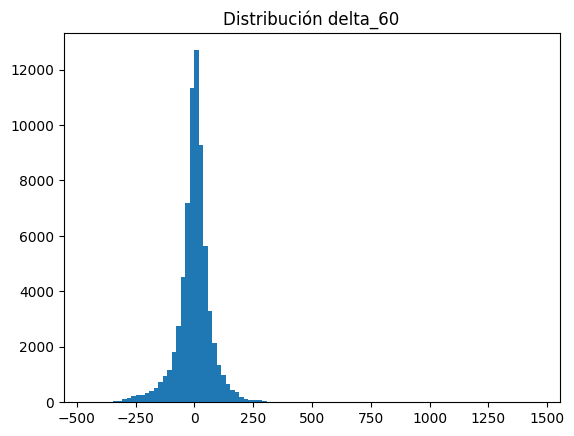

In [38]:
import matplotlib.pyplot as plt

plt.hist(y_test, bins=100)
plt.title("Distribución delta_60")
plt.show()

In [26]:
# ============================================================
# DataFrame base de evaluación del modelo
# ============================================================

df_eval = meta_test_windows.copy()

# agregar targets y predicciones
df_eval["y_true"] = y_true
df_eval["y_pred_transformer"] = y_pred_transformer
df_eval["y_pred_mlp"] = y_pred_mlp

print("Shape df_eval:", df_eval.shape)

df_eval.head()

Shape df_eval: (70590, 41)


,date,minute_of_day,is_premarket,is_opening,is_regular,is_closing,is_overnight,is_mon,is_tue,is_wed,...,roc60_x_atr14,roc60_x_atr14_flag,roc20_minus_roc60,roc20_minus_roc60_flag,mom5_minus_mom10,mom5_minus_mom10_flag,delta_60,y_true,y_pred_transformer,y_pred_mlp
datetime,,,,,,,,,,,,,,,,,,,,,
2024-08-22 08:29:00-04:00,2024-08-22,509,0,0,0,0,1,0,0,0,...,-1.834861e-05,1,-0.063737,1,0.000388,0,30.00,-27.0,-82.504967,-9.258338
2024-08-22 08:30:00-04:00,2024-08-22,510,1,0,0,0,0,0,0,0,...,-1.425485e-05,1,-0.042511,1,0.000351,1,32.25,-23.0,-86.522400,-12.539185
2024-08-22 08:31:00-04:00,2024-08-22,511,1,0,0,0,0,0,0,0,...,9.288865e-06,1,-0.025028,1,0.000188,1,42.00,-8.5,-71.648308,-7.319961
2024-08-22 08:32:00-04:00,2024-08-22,512,1,0,0,0,0,0,0,0,...,5.272421e-06,1,-0.035035,1,-0.000163,1,22.75,4.0,-57.751888,-3.044816
2024-08-22 08:33:00-04:00,2024-08-22,513,1,0,0,0,0,0,0,0,...,5.833685e-07,1,-0.030033,1,0.000113,1,20.75,13.0,-50.509884,-2.887449


In [40]:
minute_feature_idx = df_test_split.columns.get_loc("minute_of_day")

In [41]:
mean = scaler.mean_[minute_feature_idx]
std = scaler.scale_[minute_feature_idx]

In [43]:
print(df_test_split.columns)

Index(['date', 'minute_of_day', 'is_premarket', 'is_opening', 'is_regular',
       'is_closing', 'is_overnight', 'is_mon', 'is_tue', 'is_wed', 'is_thu',
       'is_fri', 'close', 'atr_norm_14', 'atr_norm_14_flag', 'atr_norm_20',
       'atr_norm_20_flag', 'ema_60', 'ema_60_flag', 'mom_10', 'mom_10_flag',
       'mom_5', 'mom_5_flag', 'roc_20', 'roc_20_flag', 'roc_30', 'roc_30_flag',
       'roc_60', 'roc_60_flag', 'roc60_x_atr20', 'roc60_x_atr20_flag',
       'roc60_x_atr14', 'roc60_x_atr14_flag', 'roc20_minus_roc60',
       'roc20_minus_roc60_flag', 'mom5_minus_mom10', 'mom5_minus_mom10_flag',
       'delta_60'],
      dtype='object')


In [42]:
bad_windows = 0

for i in range(len(X_test)):

    minutes_scaled = X_test[i, :, minute_feature_idx]

    minutes = minutes_scaled * std + mean

    diffs = np.diff(minutes)

    if np.any((np.abs(diffs - 1) > 1e-3)):
        bad_windows += 1

print("Ventanas con saltos extraños:", bad_windows)

Ventanas con saltos extraños: 70590


In [44]:
feature_cols = [c for c in df_test_split.columns if c not in ["date", target]]
print("n_features:", len(feature_cols))
print(feature_cols)

n_features: 36
['minute_of_day', 'is_premarket', 'is_opening', 'is_regular', 'is_closing', 'is_overnight', 'is_mon', 'is_tue', 'is_wed', 'is_thu', 'is_fri', 'close', 'atr_norm_14', 'atr_norm_14_flag', 'atr_norm_20', 'atr_norm_20_flag', 'ema_60', 'ema_60_flag', 'mom_10', 'mom_10_flag', 'mom_5', 'mom_5_flag', 'roc_20', 'roc_20_flag', 'roc_30', 'roc_30_flag', 'roc_60', 'roc_60_flag', 'roc60_x_atr20', 'roc60_x_atr20_flag', 'roc60_x_atr14', 'roc60_x_atr14_flag', 'roc20_minus_roc60', 'roc20_minus_roc60_flag', 'mom5_minus_mom10', 'mom5_minus_mom10_flag']


In [45]:
minute_feature_idx = feature_cols.index("minute_of_day")
print("minute_feature_idx:", minute_feature_idx)

minute_feature_idx: 0


In [47]:
# ============================================================
# Features reales usadas para construir X_test
# ============================================================

feature_cols = [c for c in df_test_split.columns if c not in ["date", target]]

print("n_features esperadas:", len(feature_cols))
print("X_test.shape[-1]     :", X_test.shape[-1])

minute_feature_idx = feature_cols.index("minute_of_day")
print("minute_feature_idx:", minute_feature_idx)

n_features esperadas: 36
X_test.shape[-1]     : 36
minute_feature_idx: 0


In [49]:
# ============================================================
# Check 1: continuidad de minute_of_day dentro de cada día
# ============================================================

bad_days = []

for d, df_day in df_test_split.groupby("date"):
    df_day = df_day.sort_index()

    minutes = df_day["minute_of_day"].to_numpy()
    diffs = np.diff(minutes)

    # esperamos avance de 1 minuto dentro del día
    if np.any(diffs != 1):
        bad_days.append(d)

print("Días con saltos intradía extraños:", len(bad_days))
print("Primeros días problemáticos:", bad_days[:10])

Días con saltos intradía extraños: 0
Primeros días problemáticos: []


In [50]:
# ============================================================
# Check 2: cantidad teórica de ventanas intradía
# ============================================================

L = window_size

windows_by_day = []

for d, df_day in df_test_split.groupby("date"):
    df_day = df_day.sort_index()
    n = len(df_day)

    n_windows = max(0, n - L + 1)

    windows_by_day.append({
        "date": d,
        "rows_day": n,
        "windows_day": n_windows,
    })

df_windows_by_day = pd.DataFrame(windows_by_day)

print(df_windows_by_day.head())
print()
print("Total ventanas teóricas:", df_windows_by_day["windows_day"].sum())
print("Total y_test           :", len(y_test))

         date  rows_day  windows_day
0  2024-08-22       541          362
1  2024-08-23       541          362
2  2024-08-26       541          362
3  2024-08-27       541          362
4  2024-08-28       541          362

Total ventanas teóricas: 70590
Total y_test           : 70590


In [51]:
print("meta_test_windows monotónico:", meta_test_windows.index.is_monotonic_increasing)
print(meta_test_windows[["date", "minute_of_day"]].head())
print(meta_test_windows[["date", "minute_of_day"]].tail())

meta_test_windows monotónico: True
                                 date  minute_of_day
datetime                                            
2024-08-22 08:29:00-04:00  2024-08-22            509
2024-08-22 08:30:00-04:00  2024-08-22            510
2024-08-22 08:31:00-04:00  2024-08-22            511
2024-08-22 08:32:00-04:00  2024-08-22            512
2024-08-22 08:33:00-04:00  2024-08-22            513
                                 date  minute_of_day
datetime                                            
2025-06-13 14:26:00-04:00  2025-06-13            866
2025-06-13 14:27:00-04:00  2025-06-13            867
2025-06-13 14:28:00-04:00  2025-06-13            868
2025-06-13 14:29:00-04:00  2025-06-13            869
2025-06-13 14:30:00-04:00  2025-06-13            870


In [27]:
# ============================================================
# Clasificación por régimen intradía
# ============================================================

def detect_regime(row):

    if row["is_premarket"] == 1:
        return "pre_market"

    if row["is_opening"] == 1:
        return "opening"

    if row["is_regular"] == 1:
        return "regular"

    if row["is_closing"] == 1:
        return "closing"

    return "other"


df_eval["regime"] = df_eval.apply(detect_regime, axis=1)

df_eval["regime"].value_counts()

,count
regime,
regular,46995
pre_market,11700
opening,11700
other,195


In [28]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


rows = []

for regime, df_r in df_eval.groupby("regime"):

    y_t = df_r["y_true"].values

    y_pred_tfm = df_r["y_pred_transformer"].values
    y_pred_mlp = df_r["y_pred_mlp"].values

    rows.append({
        "regime": regime,
        "model": "transformer",
        "n": len(df_r),
        "R2": r2_score(y_t, y_pred_tfm),
        "MAE": mean_absolute_error(y_t, y_pred_tfm),
        "DA": directional_accuracy(y_t, y_pred_tfm),
    })

    rows.append({
        "regime": regime,
        "model": "mlp",
        "n": len(df_r),
        "R2": r2_score(y_t, y_pred_mlp),
        "MAE": mean_absolute_error(y_t, y_pred_mlp),
        "DA": directional_accuracy(y_t, y_pred_mlp),
    })


df_regime_metrics = pd.DataFrame(rows)

df_regime_metrics.sort_values(["regime", "model"])

,regime,model,n,R2,MAE,DA
1,opening,mlp,11700,0.706242,27.465561,0.724017
0,opening,transformer,11700,0.434974,27.080994,0.753504
3,other,mlp,195,-0.388286,53.055958,0.558974
2,other,transformer,195,-0.205269,53.350300,0.543590
5,pre_market,mlp,11700,0.626865,30.992153,0.780684
4,pre_market,transformer,11700,0.442314,32.257832,0.784188
7,regular,mlp,46995,0.375119,37.082935,0.731503
6,regular,transformer,46995,0.523121,30.062744,0.792595


# **1. Evaluación por régimen de mercado**


El objetivo de este análisis es evaluar si el desempeño del modelo varía según el **régimen intradía del mercado**.

En mercados intradía, la dinámica de precios no es homogénea a lo largo de la sesión.  
La liquidez, volatilidad y comportamiento de los participantes cambian significativamente entre apertura, sesión regular y cierre.

Por esta razón, es importante analizar el desempeño del modelo de forma **condicional al régimen de mercado**.


El análisis por régimen intradía muestra que el desempeño del modelo **no es homogéneo a lo largo de la jornada**, sino que depende del contexto de mercado en el que se realizan las predicciones.

Durante la **sesión regular**, que concentra la mayor cantidad de observaciones y representa el régimen más relevante desde el punto de vista operativo, el **Transformer presenta una ventaja clara sobre el MLP**. En este régimen el Transformer alcanza un mayor **R²**, menor **MAE** y mayor **Directional Accuracy (DA)**, lo que indica que:

- explica mejor la variabilidad del movimiento futuro,
- comete errores de menor magnitud,
- y acierta con mayor frecuencia la dirección del mercado.

Dado que la mayor parte de las oportunidades de trading se producen durante esta sesión, este resultado refuerza la **ventaja estructural del Transformer como modelo principal**.

En la **apertura (opening)** y en el **pre-market** se observa un comportamiento diferente. En estos regímenes el **MLP obtiene un mayor R²**, lo que sugiere una mejor capacidad para capturar la **magnitud del movimiento inicial del mercado**. Sin embargo, el Transformer mantiene una **Directional Accuracy igual o superior**, indicando una mayor consistencia en la predicción de la dirección del movimiento.

Por otra parte, el régimen **"other"** contiene muy pocas observaciones, por lo que sus métricas no son suficientemente representativas y no deben utilizarse para extraer conclusiones relevantes.

En conjunto, este análisis muestra que el comportamiento del modelo es **dependiente del régimen intradía**. La superioridad del Transformer en la **sesión regular**, que es el contexto más importante desde el punto de vista operativo, respalda su selección como **modelo principal del sistema**.

## **2 Evaluación por magnitud del movimiento**



En este análisis se evalúa el desempeño de los modelos en función de la **magnitud real del movimiento del mercado**.

La idea es separar las observaciones según el tamaño del movimiento:

- **|delta| < 10 puntos** → movimientos pequeños  
- **10 ≤ |delta| < 30 puntos** → movimientos medianos  
- **|delta| ≥ 30 puntos** → movimientos grandes  

Este análisis permite responder preguntas clave:

- ¿En qué rango de movimiento el modelo realmente agrega valor?
- ¿El modelo logra capturar correctamente movimientos grandes?
- ¿La precisión direccional mejora cuando el movimiento es significativo?

Para cada rango se calcularán:

- **R²**
- **MAE**
- **Directional Accuracy (DA)**

Este análisis es especialmente importante desde el punto de vista de trading, ya que los **movimientos grandes suelen concentrar la mayor parte del PnL potencial**.

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ============================================================
# Definición de bins por magnitud del movimiento
# ============================================================

df_eval["abs_delta"] = np.abs(df_eval["y_true"])

conditions = [
    df_eval["abs_delta"] < 10,
    (df_eval["abs_delta"] >= 10) & (df_eval["abs_delta"] < 30),
    df_eval["abs_delta"] >= 30,
]

labels = [
    "|delta| < 10",
    "10 ≤ |delta| < 30",
    "|delta| ≥ 30",
]

df_eval["movement_bucket"] = np.select(
    conditions,
    labels,
    default="unknown"
)

df_eval["movement_bucket"].value_counts()

,count
movement_bucket,
|delta| ≥ 30,36241
10 ≤ |delta| < 30,21106
|delta| < 10,13243


In [31]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

In [32]:
rows = []

for bucket, df_b in df_eval.groupby("movement_bucket"):

    y_t = df_b["y_true"].values

    y_pred_tfm = df_b["y_pred_transformer"].values
    y_pred_mlp = df_b["y_pred_mlp"].values

    rows.append({
        "movement_bucket": bucket,
        "model": "transformer",
        "n": len(df_b),
        "R2": r2_score(y_t, y_pred_tfm),
        "MAE": mean_absolute_error(y_t, y_pred_tfm),
        "DA": directional_accuracy(y_t, y_pred_tfm),
    })

    rows.append({
        "movement_bucket": bucket,
        "model": "mlp",
        "n": len(df_b),
        "R2": r2_score(y_t, y_pred_mlp),
        "MAE": mean_absolute_error(y_t, y_pred_mlp),
        "DA": directional_accuracy(y_t, y_pred_mlp),
    })

df_magnitude_metrics = pd.DataFrame(rows)

df_magnitude_metrics.sort_values(["movement_bucket","model"])

,movement_bucket,model,n,R2,MAE,DA
1,10 ≤ |delta| < 30,mlp,21106,-0.722855,18.101645,0.719179
0,10 ≤ |delta| < 30,transformer,21106,-0.645005,16.902224,0.762153
3,|delta| < 10,mlp,13243,-14.795102,15.335496,0.555388
2,|delta| < 10,transformer,13243,-14.247098,13.232410,0.592766
5,|delta| ≥ 30,mlp,36241,0.527063,51.098820,0.815568
4,|delta| ≥ 30,transformer,36241,0.520029,43.748547,0.866670


Se analizó el desempeño de los modelos **Transformer** y **MLP** en función de la **magnitud real del movimiento del mercado**.

Las observaciones se separaron en tres grupos:

- **|delta| < 10 pts** → movimientos pequeños  
- **10 ≤ |delta| < 30 pts** → movimientos medianos  
- **|delta| ≥ 30 pts** → movimientos grandes  

Las métricas evaluadas fueron:

- **R²**
- **MAE**
- **Directional Accuracy (DA)**

### Resultados

| Magnitud del movimiento | Modelo | N | R² | MAE | DA |
|---|---|---|---|---|---|
| \|delta\| < 10 | Transformer | 13243 | -14.247 | 13.23 | 0.593 |
| \|delta\| < 10 | MLP | 13243 | -14.795 | 15.34 | 0.555 |
| 10 ≤ \|delta\| < 30 | Transformer | 21106 | -0.645 | 16.90 | 0.762 |
| 10 ≤ \|delta\| < 30 | MLP | 21106 | -0.723 | 18.10 | 0.719 |
| \|delta\| ≥ 30 | Transformer | 36241 | 0.520 | 43.75 | 0.867 |
| \|delta\| ≥ 30 | MLP | 36241 | 0.527 | 51.10 | 0.816 |

---

## Interpretación de resultados

### Movimientos pequeños (|delta| < 10)

En movimientos pequeños ambos modelos presentan **R² fuertemente negativo**, lo que indica que:

- el comportamiento del mercado en este rango está dominado por **ruido microestructural**
- el movimiento futuro es **difícilmente predecible**

Esto es esperable en series financieras intradía, donde los cambios pequeños suelen estar asociados a fluctuaciones aleatorias.

Aun así, el **Transformer presenta menor MAE y mayor Directional Accuracy** que el MLP, mostrando un comportamiento ligeramente más robusto.

---

### Movimientos medianos (10 ≤ |delta| < 30)

En este rango los modelos siguen mostrando **R² negativo**, aunque considerablemente mejor que en movimientos pequeños.

El **Transformer supera al MLP en todas las métricas**:

- menor **MAE**
- mayor **Directional Accuracy**
- mejor **R²**

Esto indica que el Transformer captura de forma más consistente los movimientos de magnitud intermedia.

---

### Movimientos grandes (|delta| ≥ 30)

En este rango aparece el resultado más importante del análisis:

- ambos modelos presentan **R² positivo (~0.52)**
- la **Directional Accuracy es muy alta**

| Modelo | DA |
|---|---|
| Transformer | **0.867** |
| MLP | 0.816 |

Esto significa que los modelos logran capturar correctamente **la dirección del movimiento en más del 80% de los casos** cuando el mercado se mueve de forma significativa.

Además, el **Transformer muestra un MAE considerablemente menor**, lo que indica una mejor estimación de la magnitud del movimiento.

---

## Conclusión

El análisis por magnitud del movimiento revela un patrón claro:

- Los **movimientos pequeños son esencialmente ruido**, por lo que ningún modelo logra explicarlos adecuadamente.
- En **movimientos medianos**, el Transformer comienza a mostrar ventaja frente al MLP.
- En **movimientos grandes**, ambos modelos funcionan bien, pero el **Transformer presenta mayor precisión direccional y menor error medio**.

Desde la perspectiva de trading, este resultado es especialmente relevante, ya que los **movimientos grandes concentran la mayor parte del potencial de PnL**.

Por lo tanto, el modelo resulta **mucho más confiable cuando predice movimientos de gran magnitud**, lo cual abre la puerta a estrategias basadas en **thresholds de predicción**.